# EDA 13: CCLE miRNA Expression

## Purpose

`13_CCLE_miRNA_20181103.gct` measures microRNAs — short regulatory RNAs that silence other genes
post-transcriptionally, a distinct regulatory layer from the RNA expression notebooks 01–03
measure directly. Like metabolomics (notebook 12), `docs/PROJECT_ARCHITECTURE.md` §6 expects this
layer to fail the gene-addressable (A1) admission criterion — a miRNA is not the researcher's query
gene, though it can regulate it. This notebook supplies the evidence for that verdict.

**Source, release, grain:** CCLE miRNA expression, 2018-11-03 release, GCT v1.2 format (2 header
rows — fails plain `read_csv` without `skiprows=2`). 734 miRNAs × 954 cell lines, columns keyed by
legacy `CCLE_ID` (`NAME_TISSUE`).

## Questions this notebook must answer

1. Does the GCT file load correctly (2-row header skip, then transpose to cell-line rows)?
2. What fraction of the 734 miRNAs are human vs. viral in origin?
3. Which miRNAs carry the most cross-line signal?
4. Does miRNA structure correspond to lineage, the way RNA expression does?
5. Do any cell lines carry viral miRNAs — a biological fingerprint of virus-driven cancers?

**Interpretation rule:** a value present for a (miRNA, cell line) pair is `measured`; a cell line
absent from the 954-column set is `not_assayed` for miRNA entirely — there is no documented
partial/zero-detection distinction for this layer the way HPA or DepMap RNA have one.

## Column dictionary

| Field | Meaning | Notes |
|---|---|---|
| row index (after transpose) | `CCLE_ID` (`NAME_TISSUE`) | legacy key — bridge to file 9's `CCLE_Name` |
| column (miRNA name) | e.g. `hsa-miR-21-5p` | `hsa-` = human; `kshv-`/`mcv-` = viral miRNAs the host cell carries |
| cell values | raw expression (RPM-like) | not log-transformed — apply `log1p` |

## 1. Loading the GCT format correctly

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'data' / 'raw' / 'gene_expression').exists():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the az-team25 repo (data/raw/ not found).')


ROOT = find_project_root(Path.cwd())
NON_GENE_EXPRESSION = ROOT / 'data' / 'raw' / 'non_gene_expression'
NOMENCLATURE = ROOT / 'data' / 'raw' / 'nomenclature'

In [2]:
raw = pd.read_csv(NON_GENE_EXPRESSION / '13_CCLE_miRNA_20181103.gct', sep='\t', skiprows=2, index_col=0)
raw.index.name = 'probe_id'
print(f"Raw shape (rows=probes, cols=Description + cell lines): {raw.shape}")
raw[['Description']].head(3)

Raw shape (rows=probes, cols=Description + cell lines): (734, 955)


,Description
probe_id,
nmiR00001.1,hsa-let-7a
nmiR00002.1,hsa-let-7b
nmiR00003.1,hsa-let-7c


In [3]:
mirna_name = raw['Description']
df = raw.drop(columns=['Description']).T.copy()
df.columns = df.columns.map(mirna_name)
df.index.name = 'cell_line'
print(f"Shape after transpose: {df.shape}  (rows=cell lines, cols=miRNAs by name)")
print(f"Sample miRNA names: {df.columns[:5].tolist()}")

Shape after transpose: (954, 734)  (rows=cell lines, cols=miRNAs by name)
Sample miRNA names: ['hsa-let-7a', 'hsa-let-7b', 'hsa-let-7c', 'hsa-let-7d', 'hsa-let-7e']


### Why this EDA check matters

GCT is a specialised genomics format with two metadata header rows before the data — loading it
with plain defaults silently misreads the header as data. **A second, easy-to-miss trap:** the
GCT's row index is an internal probe ID (`nmiR00001.1`), not a miRNA name — the human-readable
name (`hsa-let-7a`) lives in the `Description` column. Transposing before mapping `Description`
onto the columns (as the restored source notebook did) silently produces meaningless probe-ID
column names and makes every downstream `str.startswith('hsa-miR')` check return zero matches.
This is exactly that bug, caught by re-running the notebook rather than trusting the original.

## 2. miRNA class breakdown (human vs. viral)

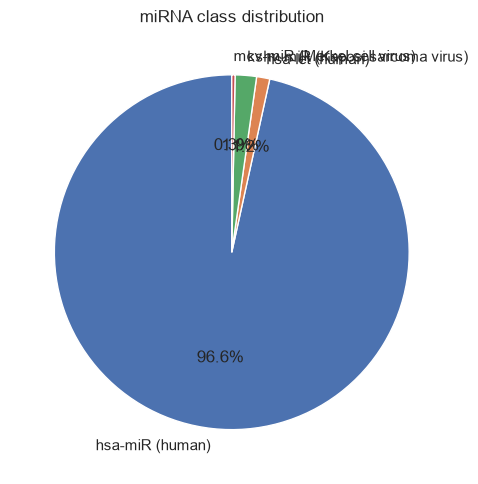

{'hsa-miR (human)': 646, 'hsa-let (human)': 8, 'kshv-miR (Kaposi sarcoma virus)': 13, 'mcv-miR (Merkel cell virus)': 2}


In [4]:
classes = {
    'hsa-miR (human)': df.columns.str.startswith('hsa-miR'),
    'hsa-let (human)': df.columns.str.startswith('hsa-let'),
    'kshv-miR (Kaposi sarcoma virus)': df.columns.str.startswith('kshv'),
    'mcv-miR (Merkel cell virus)': df.columns.str.startswith('mcv'),
}
counts = {k: int(v.sum()) for k, v in classes.items()}
counts = {k: v for k, v in counts.items() if v > 0}
fig, ax = plt.subplots(figsize=(6, 5))
ax.pie(counts.values(), labels=counts.keys(), autopct='%1.1f%%', startangle=90)
ax.set_title('miRNA class distribution')
plt.tight_layout(); plt.show()
print(counts)

### Why this EDA check matters

The presence of viral miRNA probes (Kaposi sarcoma herpesvirus, Merkel cell polyomavirus) alongside
human miRNAs means a nonzero reading for those specific columns is itself a biological finding —
evidence the cell line carries a viral genome, not routine host gene regulation. Worth flagging
explicitly rather than folding into the generic miRNA value distribution.

## 3. Most variable miRNAs and PCA structure

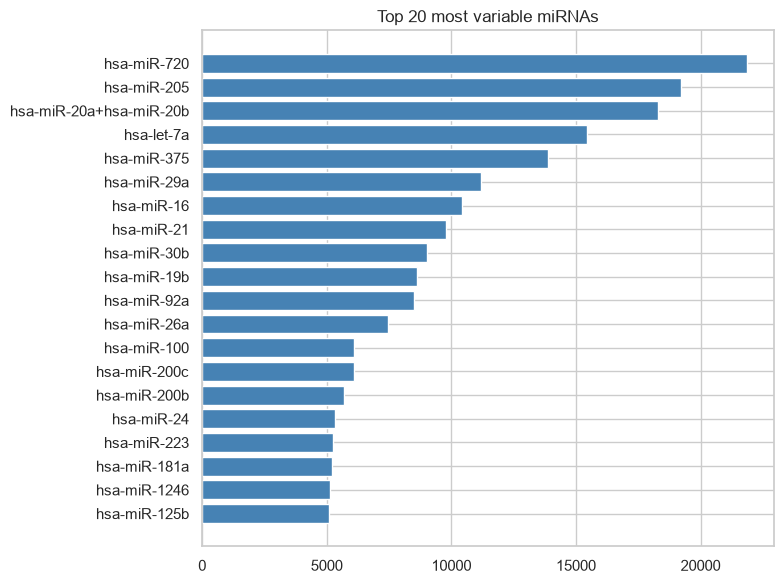

In [5]:
mir_std = df.std().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
top20 = mir_std.head(20)
ax.barh(top20.index[::-1], top20.values[::-1], color='steelblue')
ax.set_title('Top 20 most variable miRNAs')
plt.tight_layout(); plt.show()

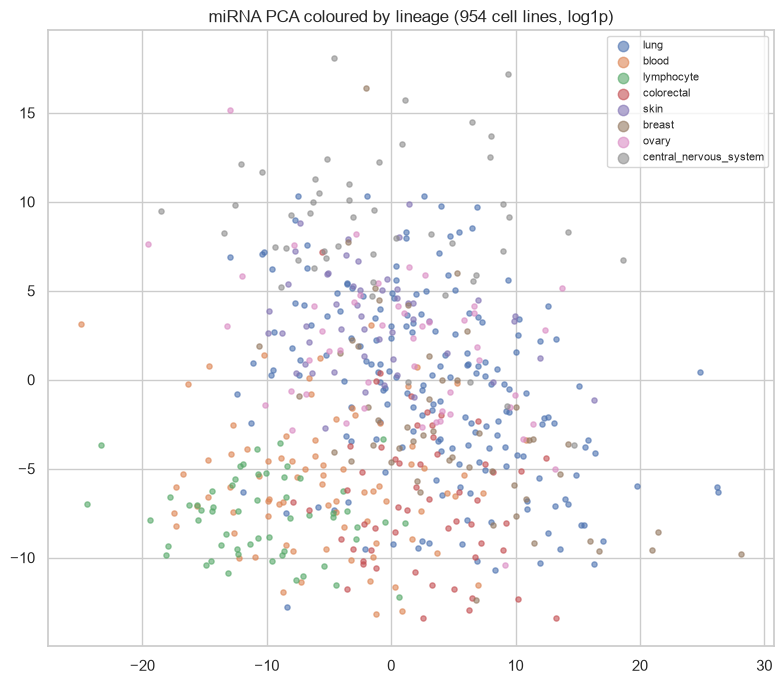

In [6]:
df9 = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['CCLE_Name', 'lineage'])
lineage = df9.dropna(subset=['CCLE_Name']).drop_duplicates('CCLE_Name').set_index('CCLE_Name')['lineage']
coords = PCA(n_components=2, random_state=42).fit_transform(np.log1p(df.values))
lins = df.index.map(lineage).values
top_lineages = pd.Series(lins).value_counts().head(8).index

fig, ax = plt.subplots(figsize=(8, 7))
for lin in top_lineages:
    mask = lins == lin
    ax.scatter(coords[mask, 0], coords[mask, 1], s=14, alpha=0.6, label=lin)
ax.legend(fontsize=8, markerscale=2)
ax.set_title(f'miRNA PCA coloured by lineage ({len(df)} cell lines, log1p)')
plt.tight_layout(); plt.show()

### Why this EDA check matters

Same logic as metabolomics (notebook 12) and RNA (notebook 02): variance identifies which miRNAs
distinguish cell lines, and lineage-coloured PCA is the descriptive check for whether this
regulatory layer carries real tissue-of-origin signal — again, a candidate reason to keep it as
context even without a per-gene score.

## 4. Identity join and coverage

In [7]:
df9_full = pd.read_csv(NOMENCLATURE / '9_DepMap_sample_info.csv', usecols=['DepMap_ID', 'CCLE_Name'])
mirna_ccle = set(df.index)
matched = mirna_ccle & set(df9_full['CCLE_Name'].dropna())
print(f"miRNA cell lines (CCLE_ID)              : {len(mirna_ccle)}")
print(f"Resolve to primary spine via CCLE_Name  : {len(matched)} ({len(matched)/len(mirna_ccle):.1%})")

miRNA cell lines (CCLE_ID)              : 954
Resolve to primary spine via CCLE_Name  : 950 (99.6%)


### Why this EDA check matters

Unlike metabolomics (which carries `DepMap_ID` directly), miRNA is keyed only by the legacy
`CCLE_ID` — the join to the primary spine depends entirely on file 9's `CCLE_Name` column staying
populated and correctly formatted.

## Decisions carried into the next notebooks

1. **Load with `skiprows=2` and transpose** — the GCT format will silently misparse otherwise.
2. **This layer has no per-gene mapping** — same A1 verdict expectation as metabolomics: candidate
   for model-level context/filter, not a scored layer, pending `docs/plan/METHOD_DECISION.md`.
3. **Nonzero viral miRNA columns (kshv-/mcv-) are a distinct biological finding**, not routine
   expression — worth a dedicated flag on any result card for a virus-associated cancer type.
4. Values are raw — apply `log1p` before any distributional or PCA use.
5. **Limitation:** the identity join in §4 relies solely on `CCLE_Name` string matching (no
   Cellosaurus bridge computed here) — a stricter join would cross-check via `RRID`/`CVCL_` as
   notebooks 01 and 03 did.